# Math 280: Mathematical and Statistical Foundations of Data Science
## Parameter Identifiability: Profile Likelihood
### UC Merced | Spring 2026 | S. Sindi

---

A model is **structurally identifiable** if — given perfect, noise-free data — its parameters can be uniquely recovered from the observations. But in practice we never have perfect data. **Practical identifiability** asks a sharper question: given the amount and quality of data we actually have, can we estimate the parameters with reasonable precision?

The **profile likelihood** is the main tool for answering this question. It lets us visualise, for each parameter individually, how sharply the data pins down that parameter's value.

This notebook works through two examples:

| Example | Model | Question |
|---------|-------|----------|
| 1 | Logistic growth | All three parameters identifiable — profile likelihoods have clear peaks |

**How to use this notebook:** Run every cell in order. Read the markdown carefully — it explains the mathematics behind each plot. The key experiment is to **change the noise level** (marked clearly below) and re-run, watching how identifiability degrades as noise increases.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.stats import chi2

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

SEED = 42
rng  = np.random.default_rng(SEED)

print('Ready.')

Ready.


---
# Part 1 — Logistic Growth

## The Model

The logistic growth ODE is:
$$\frac{dN}{dt} = rN\left(1 - \frac{N}{K}\right), \qquad N(0) = N_0.$$

It has an exact closed-form solution:
$$N(t) = \frac{K}{1 + \left(\dfrac{K - N_0}{N_0}\right)e^{-rt}}.$$

The three parameters are:
- $r > 0$ — the intrinsic growth rate
- $K > 0$ — the carrying capacity (the long-run population size)
- $N_0 > 0$ — the initial population size

## The Statistical Model

We assume observations are generated by adding independent Gaussian noise to the true curve:
$$y_i = N(t_i;\, r, K, N_0) + \varepsilon_i, \qquad \varepsilon_i \overset{\text{iid}}{\sim} \mathcal{N}(0,\sigma^2).$$

Given $\sigma^2$, the log-likelihood is:
$$\ell(r, K, N_0) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n \bigl(y_i - N(t_i)\bigr)^2.$$

Maximising $\ell$ over the parameters is equivalent to minimising the **sum of squared errors (SSE)**:
$$\mathrm{SSE}(r,K,N_0) = \sum_{i=1}^n \bigl(y_i - N(t_i)\bigr)^2.$$

The **maximum likelihood estimate (MLE)** is the parameter triple $(\hat{r}, \hat{K}, \hat{N}_0)$ that minimises SSE.

## Section 1.1 — Generate Synthetic Data

We set the true parameters, evaluate the logistic solution at a grid of time points, and add Gaussian noise.

> **Experiment:** After working through the notebook once, come back and change `SIGMA` below. Try `SIGMA = 5` (low noise) and `SIGMA = 30` (high noise). How do the profile likelihoods change?

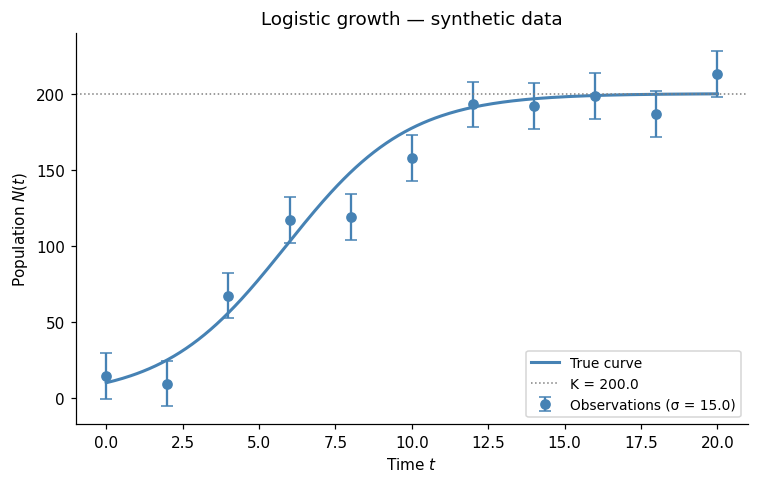

True parameters: r = 0.5, K = 200.0, N₀ = 10.0
Noise level:     σ = 15.0
Number of observations: 11


In [2]:
# ── TRUE PARAMETERS ────────────────────────────────────────────────────────────
R_TRUE  = 0.5    # intrinsic growth rate
K_TRUE  = 200.0  # carrying capacity
N0_TRUE = 10.0   # initial population

# ── NOISE LEVEL — CHANGE THIS AND RE-RUN ──────────────────────────────────────
SIGMA = 15.0     # standard deviation of additive Gaussian noise

# ── TIME POINTS AND SOLUTION ───────────────────────────────────────────────────
t_obs = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20], dtype=float)
t_fine = np.linspace(0, 20, 300)

def logistic(t, r, K, N0):
    """Closed-form logistic growth solution."""
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

N_true = logistic(t_obs, R_TRUE, K_TRUE, N0_TRUE)
y_obs  = N_true + rng.normal(0, SIGMA, size=len(t_obs))
y_obs  = np.maximum(y_obs, 0)   # populations can't be negative

# ── PLOT ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t_fine, logistic(t_fine, R_TRUE, K_TRUE, N0_TRUE),
        'steelblue', linewidth=2, label='True curve')
ax.errorbar(t_obs, y_obs, yerr=SIGMA, fmt='o', color='steelblue',
            capsize=4, markersize=6, label=f'Observations (σ = {SIGMA})')
ax.axhline(K_TRUE, color='grey', linestyle=':', linewidth=1, label=f'K = {K_TRUE}')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Population $N(t)$')
ax.set_title('Logistic growth — synthetic data')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'True parameters: r = {R_TRUE}, K = {K_TRUE}, N₀ = {N0_TRUE}')
print(f'Noise level:     σ = {SIGMA}')
print(f'Number of observations: {len(t_obs)}')

## Section 1.2 — Maximum Likelihood Estimation

We find the MLE by minimising the SSE using `scipy.optimize.minimize`. This is a nonlinear optimisation problem — we use the L-BFGS-B method with bounds to ensure parameters stay positive.

The MLE gives us a single best-fit point $\hat{\theta} = (\hat{r}, \hat{K}, \hat{N}_0)$. But a point estimate alone does not tell us how *certain* we are about each parameter. That is what the profile likelihood does.

MLE estimates:
  r̂  = 0.4038   (true: 0.5)
  K̂  = 201.24  (true: 200.0)
  N̂₀ = 15.16  (true: 10.0)
  σ̂  = 12.45   (true: 15.0)
  SSE at MLE = 1706.14


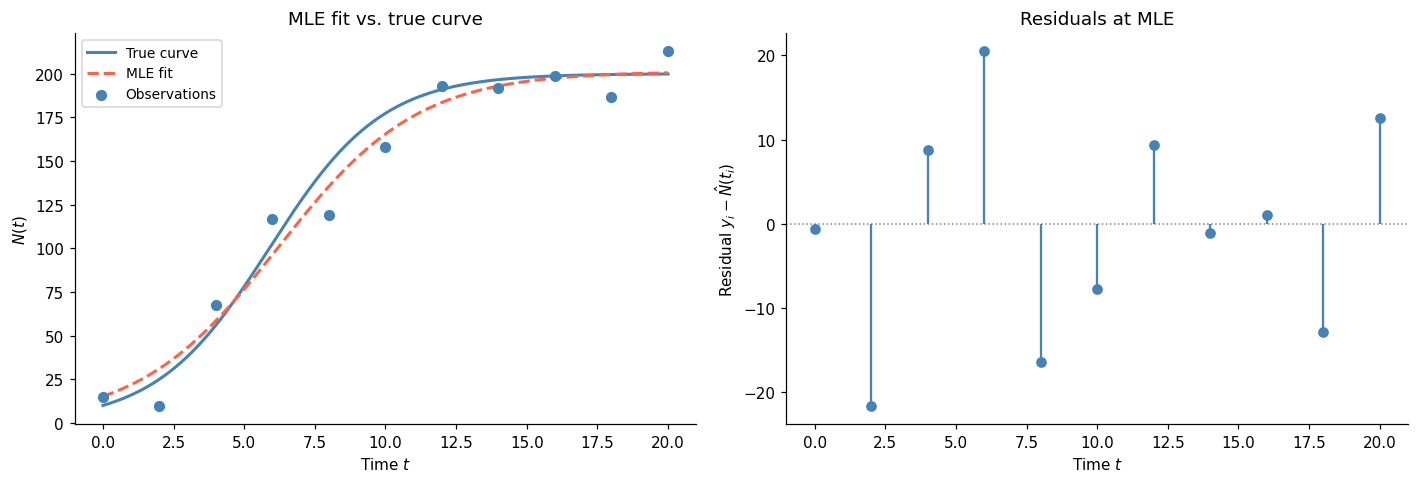

In [3]:
def sse_logistic(params):
    """SSE between observations and logistic model."""
    r, K, N0 = params
    pred = logistic(t_obs, r, K, N0)
    return np.sum((y_obs - pred) ** 2)

# Optimise — try multiple starting points to avoid local minima
best_result = None
for r0, K0, N00 in [(0.3, 150, 5), (0.5, 200, 10), (0.8, 250, 20), (0.2, 100, 15)]:
    res = minimize(sse_logistic, x0=[r0, K0, N00],
                   bounds=[(0.01, 5.0), (50.0, 500.0), (0.1, 50.0)],
                   method='L-BFGS-B')
    if best_result is None or res.fun < best_result.fun:
        best_result = res

r_hat, K_hat, N0_hat = best_result.x
SSE_hat = best_result.fun
n = len(t_obs)
sigma_hat = np.sqrt(SSE_hat / n)   # MLE of sigma

print(f'MLE estimates:')
print(f'  r̂  = {r_hat:.4f}   (true: {R_TRUE})')
print(f'  K̂  = {K_hat:.2f}  (true: {K_TRUE})')
print(f'  N̂₀ = {N0_hat:.2f}  (true: {N0_TRUE})')
print(f'  σ̂  = {sigma_hat:.2f}   (true: {SIGMA})')
print(f'  SSE at MLE = {SSE_hat:.2f}')

# Maximum log-likelihood (up to constant)
loglik_hat = -0.5 * n * np.log(2 * np.pi * sigma_hat**2) - SSE_hat / (2 * sigma_hat**2)

# Plot MLE fit
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: fitted curve
axes[0].plot(t_fine, logistic(t_fine, R_TRUE, K_TRUE, N0_TRUE),
             'steelblue', linewidth=2, label='True curve', zorder=3)
axes[0].plot(t_fine, logistic(t_fine, r_hat, K_hat, N0_hat),
             'tomato', linewidth=2, linestyle='--', label='MLE fit', zorder=3)
axes[0].scatter(t_obs, y_obs, color='steelblue', zorder=4, s=40, label='Observations')
axes[0].set_xlabel('Time $t$'); axes[0].set_ylabel('$N(t)$')
axes[0].set_title('MLE fit vs. true curve')
axes[0].legend(fontsize=9)

# Right: residuals
residuals = y_obs - logistic(t_obs, r_hat, K_hat, N0_hat)
axes[1].axhline(0, color='grey', linewidth=1, linestyle=':')
axes[1].stem(t_obs, residuals, linefmt='steelblue', markerfmt='o', basefmt=' ')
axes[1].set_xlabel('Time $t$'); axes[1].set_ylabel('Residual $y_i - \\hat{N}(t_i)$')
axes[1].set_title('Residuals at MLE')

plt.tight_layout()
plt.show()

The MLE fit should lie close to the true curve, and residuals should look roughly random around zero (no systematic pattern). If you increased `SIGMA`, the residuals will be larger but should still be centred around zero.

## Section 1.3 — The Profile Likelihood

### What is a profile likelihood?

The **full log-likelihood** $\ell(r, K, N_0)$ is a surface in three-dimensional parameter space. We cannot easily visualise a 3D surface, so we project it.

The **profile log-likelihood** for a single parameter $\theta_j$ is obtained by fixing $\theta_j$ at a grid of values and **optimising over all other parameters** at each grid point:
$$\ell_p(\theta_j) = \max_{\theta_{-j}} \; \ell(\theta_j, \theta_{-j}).$$

This gives a curve — one number for each value of $\theta_j$ — that shows how the best possible fit changes as we force $\theta_j$ away from its MLE.

### The confidence threshold

By Wilks' theorem, the **95% confidence interval** for $\theta_j$ is the set of values where the profile log-likelihood does not drop too far below its maximum:
$$\left\{\theta_j \;:\; \ell_p(\theta_j) \geq \ell_p(\hat{\theta}_j) - \frac{1}{2}\chi^2_{1,0.95}\right\}$$
where $\chi^2_{1,0.95} \approx 3.84$. The threshold is a horizontal line at $\ell_p(\hat{\theta}_j) - 1.92$.

**Identifiability criterion:** A parameter is *practically identifiable* if its profile likelihood has a clear, finite peak and the confidence interval is bounded. If the profile is flat or has no peak, the data cannot pin down that parameter — it is non-identifiable.

In [4]:
# ── Helper: compute log-likelihood ────────────────────────────────────────────
def loglik(params, sigma):
    """Gaussian log-likelihood (up to constant) for the logistic model."""
    r, K, N0 = params
    pred = logistic(t_obs, r, K, N0)
    return -0.5 * np.sum((y_obs - pred) ** 2) / sigma**2

# Use sigma_hat estimated at MLE
threshold = loglik([r_hat, K_hat, N0_hat], sigma_hat) - 0.5 * chi2.ppf(0.95, df=1)
print(f'95% CI threshold: {threshold:.3f}  (= max log-lik − {0.5*chi2.ppf(0.95,df=1):.3f})')

95% CI threshold: -7.421  (= max log-lik − 1.921)


In [5]:
# ── Profile likelihood for r ───────────────────────────────────────────────────
# For each fixed value of r, optimise over K and N0

r_grid     = np.linspace(0.15, 1.2, 60)
prof_r     = np.full(len(r_grid), np.nan)

for i, r_fixed in enumerate(r_grid):
    def obj(params):   # minimise SSE over K, N0 with r fixed
        K_, N0_ = params
        pred = logistic(t_obs, r_fixed, K_, N0_)
        return np.sum((y_obs - pred) ** 2)
    res = minimize(obj, x0=[K_hat, N0_hat],
                   bounds=[(50.0, 500.0), (0.1, 50.0)],
                   method='L-BFGS-B')
    if res.success:
        K_opt, N0_opt = res.x
        prof_r[i] = loglik([r_fixed, K_opt, N0_opt], sigma_hat)

print('Profile likelihood for r: done')

Profile likelihood for r: done


In [6]:
# ── Profile likelihood for K ───────────────────────────────────────────────────
K_grid = np.linspace(100, 350, 60)
prof_K = np.full(len(K_grid), np.nan)

for i, K_fixed in enumerate(K_grid):
    def obj(params):
        r_, N0_ = params
        pred = logistic(t_obs, r_, K_fixed, N0_)
        return np.sum((y_obs - pred) ** 2)
    res = minimize(obj, x0=[r_hat, N0_hat],
                   bounds=[(0.01, 5.0), (0.1, 50.0)],
                   method='L-BFGS-B')
    if res.success:
        r_opt, N0_opt = res.x
        prof_K[i] = loglik([r_opt, K_fixed, N0_opt], sigma_hat)

print('Profile likelihood for K: done')

Profile likelihood for K: done


In [8]:
# ── Profile likelihood for N0 ──────────────────────────────────────────────────
N0_grid = np.linspace(1, 40, 60)
prof_N0 = np.full(len(N0_grid), np.nan)

for i, N0_fixed in enumerate(N0_grid):
    def obj(params):
        r_, K_ = params
        pred = logistic(t_obs, r_, K_, N0_fixed)
        return np.sum((y_obs - pred) ** 2)
    res = minimize(obj, x0=[r_hat, K_hat],
                   bounds=[(0.01, 5.0), (50.0, 500.0)],
                   method='L-BFGS-B')
    if res.success:
        r_opt, K_opt = res.x
        prof_N0[i] = loglik([r_opt, K_opt, N0_fixed], sigma_hat)

print('Profile likelihood for N₀: done')

Profile likelihood for N₀: done


### Plotting the profile likelihoods

Each panel below shows the profile log-likelihood for one parameter. The dashed horizontal line is the 95% confidence threshold. The vertical red line marks the true parameter value.

**What to look for:**
- A clear, sharp **peak** near the true value → the parameter is well-identified by the data.
- The confidence interval (the segment of the curve above the threshold) should be **finite and bounded** on both sides.
- If you increase `SIGMA`, the peaks will become **flatter and wider** — the data are less informative, so confidence intervals grow.

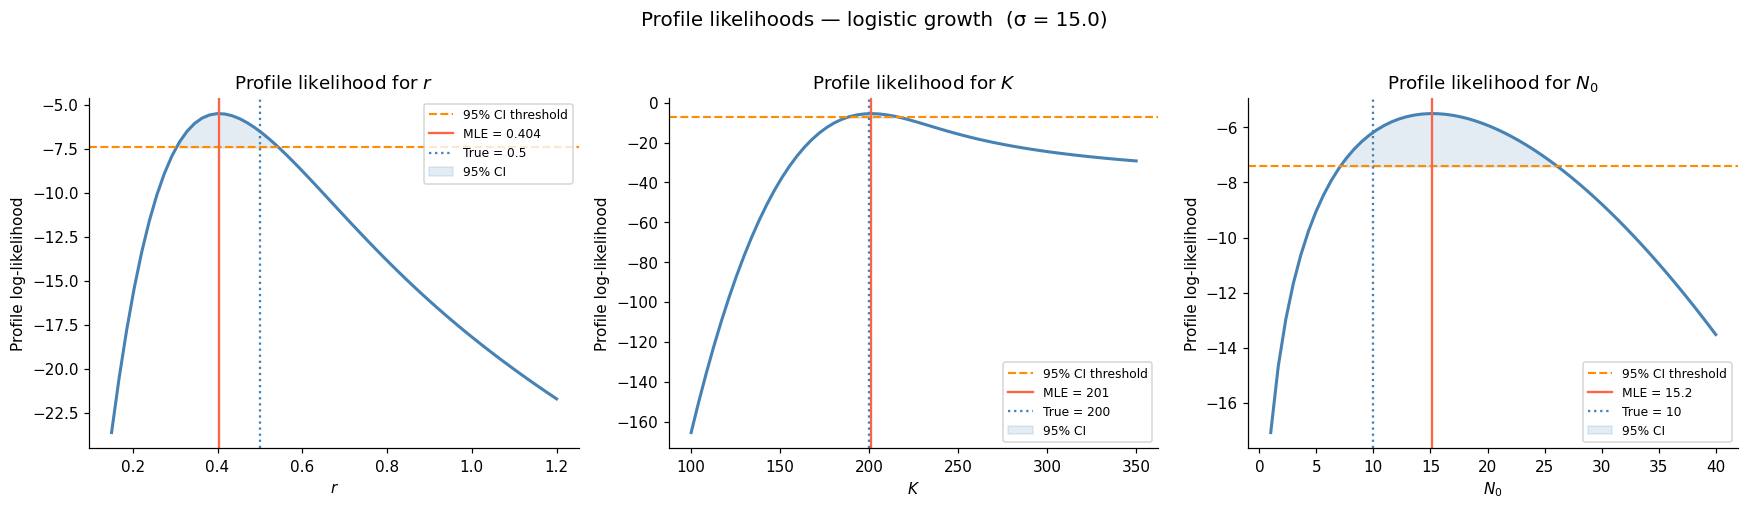

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

plot_specs = [
    (axes[0], r_grid,  prof_r,  r_hat,  R_TRUE,  '$r$',   'Profile likelihood for $r$'),
    (axes[1], K_grid,  prof_K,  K_hat,  K_TRUE,  '$K$',   'Profile likelihood for $K$'),
    (axes[2], N0_grid, prof_N0, N0_hat, N0_TRUE, '$N_0$', 'Profile likelihood for $N_0$'),
]

for ax, grid, prof, mle_val, true_val, xlabel, title in plot_specs:
    ax.plot(grid, prof, 'steelblue', linewidth=2)
    ax.axhline(threshold, color='darkorange', linestyle='--', linewidth=1.4,
               label='95% CI threshold')
    ax.axvline(mle_val,  color='tomato',    linestyle='-',  linewidth=1.5,
               label=f'MLE = {mle_val:.3g}')
    ax.axvline(true_val, color='steelblue', linestyle=':',  linewidth=1.5,
               label=f'True = {true_val:.3g}')

    # Shade the 95% CI region
    above = prof >= threshold
    if above.any():
        ax.fill_between(grid, threshold, prof,
                        where=above, alpha=0.15, color='steelblue',
                        label='95% CI')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Profile log-likelihood')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle(f'Profile likelihoods — logistic growth  (σ = {SIGMA})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Each parameter has a clear, finite peak. The 95% confidence interval (shaded region) is bounded on both sides for all three parameters. This is what **practical identifiability** looks like: the data are informative enough to pin down each parameter individually.

Now go back and try `SIGMA = 40`. You should see the profiles flatten — especially for $N_0$, which is only informed by the early part of the curve. At high noise levels, the confidence interval for $N_0$ may hit the edge of the grid, signalling that it is becoming practically non-identifiable with this dataset.

## Section 1.4 — The Joint Likelihood Surface

The profile likelihoods are 1D slices through the full likelihood surface. We can also look at the **joint likelihood surface** for pairs of parameters by fixing the third at its MLE and plotting the log-likelihood as a 2D heatmap.

For an identifiable model with Gaussian noise, we expect **elliptical contours** centred near the true parameter values. Elongated or tilted ellipses indicate correlation between parameters — they can trade off against each other to some extent.

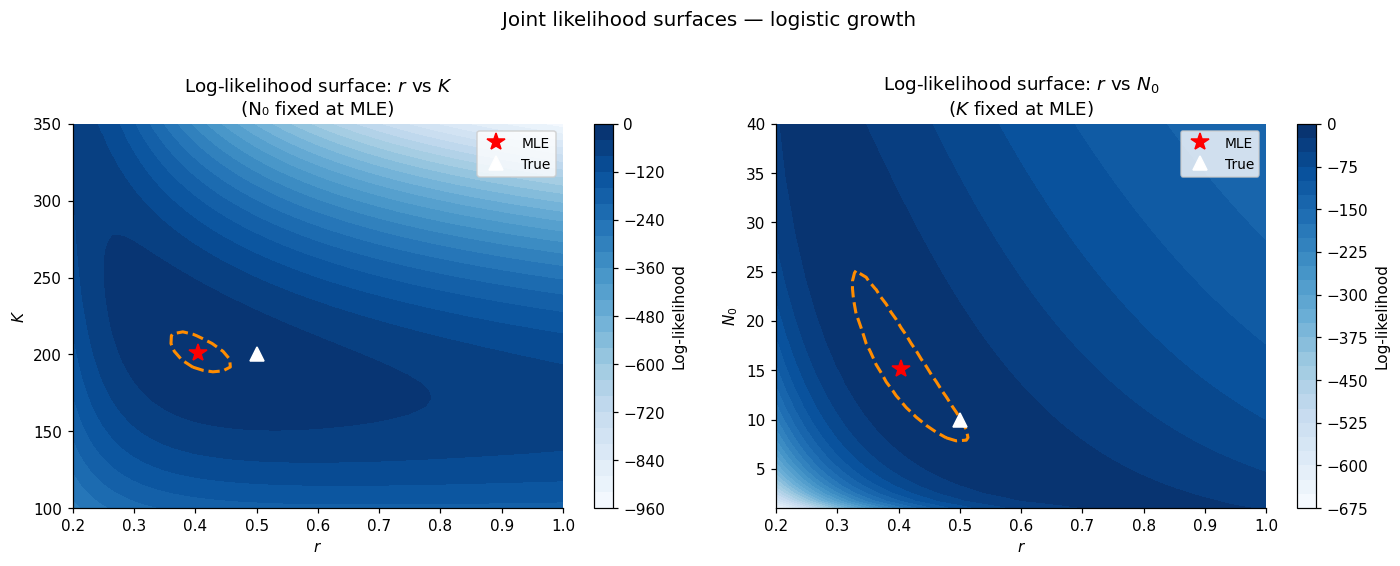

In [10]:
# ── 2D log-likelihood surface: r vs K (N0 fixed at MLE) ───────────────────────
r_2d  = np.linspace(0.2, 1.0, 50)
K_2d  = np.linspace(100, 350, 50)
RR, KK = np.meshgrid(r_2d, K_2d)
LL_rK  = np.array([
    loglik([r_, K_, N0_hat], sigma_hat)
    for r_, K_ in zip(RR.ravel(), KK.ravel())
]).reshape(RR.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: r vs K
im = axes[0].contourf(r_2d, K_2d, LL_rK, levels=30, cmap='Blues')
axes[0].contour(r_2d, K_2d, LL_rK,
                levels=[threshold], colors='darkorange',
                linewidths=2, linestyles='--')
axes[0].plot(r_hat, K_hat, 'r*', markersize=12, label='MLE')
axes[0].plot(R_TRUE, K_TRUE, 'w^', markersize=9, label='True')
axes[0].set_xlabel('$r$'); axes[0].set_ylabel('$K$')
axes[0].set_title('Log-likelihood surface: $r$ vs $K$\n(N₀ fixed at MLE)')
axes[0].legend(fontsize=9)
plt.colorbar(im, ax=axes[0], label='Log-likelihood')

# Right: r vs N0
N0_2d  = np.linspace(1, 40, 50)
RR2, NN = np.meshgrid(r_2d, N0_2d)
LL_rN  = np.array([
    loglik([r_, K_hat, N0_], sigma_hat)
    for r_, N0_ in zip(RR2.ravel(), NN.ravel())
]).reshape(RR2.shape)

im2 = axes[1].contourf(r_2d, N0_2d, LL_rN, levels=30, cmap='Blues')
axes[1].contour(r_2d, N0_2d, LL_rN,
                levels=[threshold], colors='darkorange',
                linewidths=2, linestyles='--')
axes[1].plot(r_hat, N0_hat, 'r*', markersize=12, label='MLE')
axes[1].plot(R_TRUE, N0_TRUE, 'w^', markersize=9, label='True')
axes[1].set_xlabel('$r$'); axes[1].set_ylabel('$N_0$')
axes[1].set_title('Log-likelihood surface: $r$ vs $N_0$\n($K$ fixed at MLE)')
axes[1].legend(fontsize=9)
plt.colorbar(im2, ax=axes[1], label='Log-likelihood')

plt.suptitle('Joint likelihood surfaces — logistic growth', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The orange dashed contour is the 95% confidence region boundary. Notice:
- The contours are roughly elliptical — the model is well-behaved near the MLE.
- The $r$–$K$ surface shows a **negative correlation**: if we increase $r$ slightly, a smaller $K$ can compensate to maintain a similar fit. This is visible as a tilted ellipse.
- Despite the correlation, both parameters are still identifiable — the confidence region is closed and bounded.